Parte 1:

In [ ]:
import math

# Parâmetros de entrada
# Mass
m = 0.073 #(Kg)

# Gravity
g = 9.81 #(m/s^2)

# Magnetic constant
k = 6.51e-5 #(Nm^2/A^2)

# Resistance
R = 11.0 #(Ohm)


# Condição inicial
# Initial position (Setpoint/Equilibrium point)
x0 = 8.5e-3 #(m)


# Initial velocity
v0 = 0.0 #(m/s)


# Condição de equilíbrio
# Na condição de equilíbrio a força peso se iguala à força magnética: m*g = (k/2) * (i0^2 / x0^2)
# Isolando i0, temos:
i0 = math.sqrt((2 * m * g * (x0**2)) / k) #(A)

# Equilibrium voltage
u0 = R * i0 #(V)


# Ganhos do Controlador PID

Kp = 7000.0 
Ki = 1000.0  
Kd = 250.0  

E a representação em espaço de estados é descrita como: 

In [ ]:
# Magnetic force fm
def fm(i, x):
    return k/2*i*i/x/x

# Force Factor
def Bl(i, x):
    return k/2*i/x/x #(N/A)

# Inductance
def L(x):
    return k/x #(H)

# State space representation in vector form
# dy = y´ = function(y,t)
# y = [i, x, v, E]

def f(t, y):
    # 1. Desempacotando o vetor de estados completo 
    i, x, v, E = y
    
    # 2. Cálculo do erro e da derivada do erro
    e = x - x0
    # A derivada do erro (de/dt) é a própria velocidade (v) se o setpoint (x0) for constante
    e_dot = v 
    
    # 3. Equações do controlador PID 
    delta_u = Kp * e + Ki * E + Kd * e_dot
    u = u0 + delta_u
    
    # 4. Equações diferenciais do sistema
    # di/dt 
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u/L(x)
    
    # dx/dt
    dx = v
    
    # dv/dt
    dv = g - fm(i,x)/m
    
    # dE/dt 
    dE = e
    
    # 5. Retornando o vetor de derivadas com 4 elementos
    return [di, dx, dv, dE]

Simulando o problema

In [ ]:
from scipy.integrate import solve_ivp

# Initial conditions
# y = [i,x,v]
# Perturbação epsilon de 2% 
epsilon = 0.02 * x0 
y_0 = [i0, x0 + epsilon, 0.0, 0.0]  # Incluindo a integral do erro inicial como 0

# Time span
t_0 = 0.0
t_end = 1 #(s) 


sol = solve_ivp(f, [t_0, t_end], y_0)


In [ ]:
import matplotlib.pyplot as plt

# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1,:]-x0, 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)-x_0$ (m)');
fig.suptitle('Fig. 1 - Dados da esfera');

plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
fig.suptitle('Fig. 2 - Dados da fonte');

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math

# ==========================================
# 1. Parâmetros e Condições Iniciais
# ==========================================
m = 0.073      # (Kg)
g = 9.81       # (m/s^2)
k = 6.51e-5    # (Nm^2/A^2)
R = 11.0       # (Ohm)
x0 = 8.5e-3    # (m)
v0 = 0.0       # (m/s)

# Condição de equilíbrio
i0 = math.sqrt((2 * m * g * (x0**2)) / k) # (A)
u0 = R * i0                               # (V)

# ==========================================
# 2. Ganhos do Controlador PID
# (Valores de exemplo para estabilizar a planta)
# ==========================================
Kp = 8000.0 
Ki = 4000.0  
Kd = 150.0  

# ==========================================
# 3. Funções do Sistema
# ==========================================
def fm(i, x):
    return k/2 * i**2 / x**2

def Bl(i, x):
    return k/2 * i / x**2

def L(x):
    return k / x

def f(t, y):
    i, x, v, E = y
    
    e = x - x0
    e_dot = v 
    
    delta_u = Kp * e + Ki * E + Kd * e_dot
    u = u0 + delta_u
    
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u/L(x)
    dx = v
    dv = g - fm(i,x)/m
    dE = e
    
    return [di, dx, dv, dE]

# ==========================================
# 4. Demonstração de Estabilidade (Epsilon Fixo)
# ==========================================
# Perturbação epsilon de 2% (dentro do limite < 3% da atividade)
epsilon = 0.02 * x0 
y_0 = [i0, x0 + epsilon, 0.0, 0.0]  # Incluindo a integral do erro inicial como 0

t_0 = 0.0
t_end = 0.5 # Simular por meio segundo costuma ser suficiente para esta dinâmica
t_eval = np.linspace(t_0, t_end, 1000)

sol = solve_ivp(f, [t_0, t_end], y_0, t_eval=t_eval, method='RK45')

# Plot da Posição
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1] * 1000, label='Posição x(t)') # Convertendo para mm
plt.axhline(x0 * 1000, color='r', linestyle='--', label='Setpoint x0')
plt.title(f'Resposta ao Degrau (Epsilon = 2%)')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (mm)')
plt.legend()
plt.grid(True)

# Plot da Corrente
plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[0], label='Corrente i(t)', color='orange')
plt.axhline(2.0, color='red', linestyle='--', label='Limite 2A')
plt.title('Esforço de Controle / Corrente')
plt.xlabel('Tempo (s)')
plt.ylabel('Corrente (A)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 5. Avaliação da Faixa Máxima de Epsilon
# ==========================================
print("\n--- Avaliando Faixa Máxima de Estabilidade para Epsilon ---")
epsilon_test_range = np.linspace(0.001 * x0, 0.50 * x0, 100) # Testando de 0.1% a 50% de perturbação
max_stable_epsilon = 0

for eps in epsilon_test_range:
    y_test = [i0, x0 + eps, 0.0, 0.0]
    # Simulamos um curto período
    sol_test = solve_ivp(f, [0, 0.5], y_test, method='RK45')
    
    # Verifica se a solução falhou (divergiu matematicamente)
    if not sol_test.success:
        break
        
    # Extrai a corrente máxima atingida nesta simulação
    max_current = np.max(sol_test.y[0])
    
    # Verifica erro em regime permanente (estabilidade) e limite de 2A
    final_pos_error = abs(sol_test.y[1][-1] - x0)
    
    if max_current <= 2.0 and final_pos_error < 1e-4:
        max_stable_epsilon = eps
    else:
        break # Sistema instável ou violou a corrente de 2A

percentual_maximo = (max_stable_epsilon / x0) * 100
print(f"O sistema se mantém estável (e i <= 2A) para epsilon de até: {max_stable_epsilon:.6f} m")
print(f"Isso representa uma perturbação máxima de aproximadamente {percentual_maximo:.2f}% na posição inicial.")

In [ ]:
Parte 2:

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math

# ==========================================
# Parâmetros Iniciais do Sistema
# ==========================================
m = 0.073      # (Kg)
g = 9.81       # (m/s^2)
k = 6.51e-5    # (Nm^2/A^2)
R = 11.0       # (Ohm)
x0 = 8.5e-3    # (m)

# Condição de equilíbrio
i0 = math.sqrt((2 * m * g * (x0**2)) / k)
u0 = R * i0

# Ganhos do PID (mantidos da Atividade 01)
Kp = 8000.0 
Ki = 4000.0  
Kd = 150.0  

# Funções auxiliares
def fm(i, x): return k/2 * i**2 / x**2
def Bl(i, x): return k/2 * i / x**2
def L(x): return k / x

# ==========================================
# Gerador de Ruído Interpolado
# ==========================================
def create_noise_interpolators(t_end, sd, num_points=2000):
    """Gera um sinal de ruído contínuo para não quebrar o solver RK45"""
    t_n = np.linspace(0, t_end, num_points)
    n_pos = np.random.normal(0, sd, num_points)
    
    # A derivada do ruído (ruído para o termo D do PID)
    # Numérica: dx = t_n[1] - t_n[0]
    dt = t_n[1] - t_n[0]
    n_vel = np.gradient(n_pos, dt) 
    
    def get_noise(t):
        # Interpola para obter valores nos tempos quebrados do solver
        return np.interp(t, t_n, n_pos), np.interp(t, t_n, n_vel)
    
    return get_noise

# ==========================================
# Nova Função de Espaço de Estados (com Incerteza)
# ==========================================
def f_noisy(t, y, get_noise):
    i, x, v, E = y
    
    # Captura o ruído pré-gerado para o instante t
    n_p, n_v = get_noise(t)
    
    # Medições ruidosas
    x_m = x + n_p
    v_m = v + n_v
    
    # Erro baseado na medição
    e = x_m - x0
    e_dot = v_m 
    
    # Controlador agindo sobre sinais ruidosos
    delta_u = Kp * e + Ki * E + Kd * e_dot
    u = u0 + delta_u
    
    # Equações de estado usando x e v REAIS, mas aplicando o controle 'u' ruidoso
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u/L(x)
    dx = v
    dv = g - fm(i,x)/m
    dE = e  # A integral acumula o erro medido (ruidoso)
    
    return [di, dx, dv, dE]

# ==========================================
# 2. Reavaliando a faixa de epsilon com sd = 0.04*x0
# ==========================================
print("--- 2. Reavaliando Epsilon com sd = 0.04*x0 ---")
sd_fixed = 0.04 * x0
t_end = 0.5

epsilon_test_range = np.linspace(0.001 * x0, 0.20 * x0, 50)
max_stable_epsilon_noisy = 0

for eps in epsilon_test_range:
    # A cada teste de epsilon, instanciamos o mesmo nível de ruído
    get_noise = create_noise_interpolators(t_end, sd_fixed)
    y_test = [i0, x0 + eps, 0.0, 0.0]
    
    sol_test = solve_ivp(lambda t, y: f_noisy(t, y, get_noise), 
                         [0, t_end], y_test, method='RK45')
    
    if not sol_test.success:
        break
        
    max_current = np.max(sol_test.y[0])
    
    # Verificação de estabilidade (usamos a média dos últimos instantes devido ao ruído)
    final_pos_error = abs(np.mean(sol_test.y[1][-50:]) - x0)
    
    if max_current <= 2.0 and final_pos_error < (0.1 * x0): # tolerância maior pro erro final devido ao ruído
        max_stable_epsilon_noisy = eps
    else:
        break

print(f"Com sd={sd_fixed:.6f}, o epsilon máximo estável (i<=2A) caiu para: {max_stable_epsilon_noisy:.6f} m")
print(f"Isto representa: {(max_stable_epsilon_noisy / x0) * 100:.2f}% de perturbação na posição inicial.\n")


# ==========================================
# 3. Avaliando estabilidade em relação a 'sd' (epsilon constante)
# ==========================================
print("--- 3. Avaliando a faixa de 'sd' para Epsilon constante (2%) ---")
epsilon_fixed = 0.5 * x0
y_0_fixed = [i0, x0 + epsilon_fixed, 0.0, 0.0]

sd_test_range = np.linspace(0.0, 0.10 * x0, 50) # Testando sd de 0 até 10% de x0
max_stable_sd = 0

for sd_test in sd_test_range:
    get_noise = create_noise_interpolators(t_end, sd_test)
    
    sol_test = solve_ivp(lambda t, y: f_noisy(t, y, get_noise), 
                         [0, t_end], y_0_fixed, method='RK45')
    
    if not sol_test.success:
        break
        
    max_current = np.max(sol_test.y[0])
    final_pos_error = abs(np.mean(sol_test.y[1][-50:]) - x0)
    
    if max_current <= 2.0 and final_pos_error < (0.1 * x0):
        max_stable_sd = sd_test
    else:
        break

print(f"Para epsilon={epsilon_fixed:.6f}, o desvio padrão máximo suportado pelo sistema (i<=2A) é: {max_stable_sd:.6f} m")
print(f"Isto representa um ruído sd de até {(max_stable_sd / x0) * 100:.2f}% de x0.")

--- 2. Reavaliando Epsilon com sd = 0.04*x0 ---
Com sd=0.000340, o epsilon máximo estável (i<=2A) caiu para: 0.000000 m
Isto representa: 0.00% de perturbação na posição inicial.

--- 3. Avaliando a faixa de 'sd' para Epsilon constante (2%) ---
Para epsilon=0.004250, o desvio padrão máximo suportado pelo sistema (i<=2A) é: 0.000000 m
Isto representa um ruído sd de até 0.00% de x0.


<>:97: SyntaxWarning: invalid escape sequence '\e'
<>:97: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_41824/2313651180.py:97: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Resposta da Posição com Incerteza\n(sd = 4% de $x_0$, $\epsilon$ = 2%)')


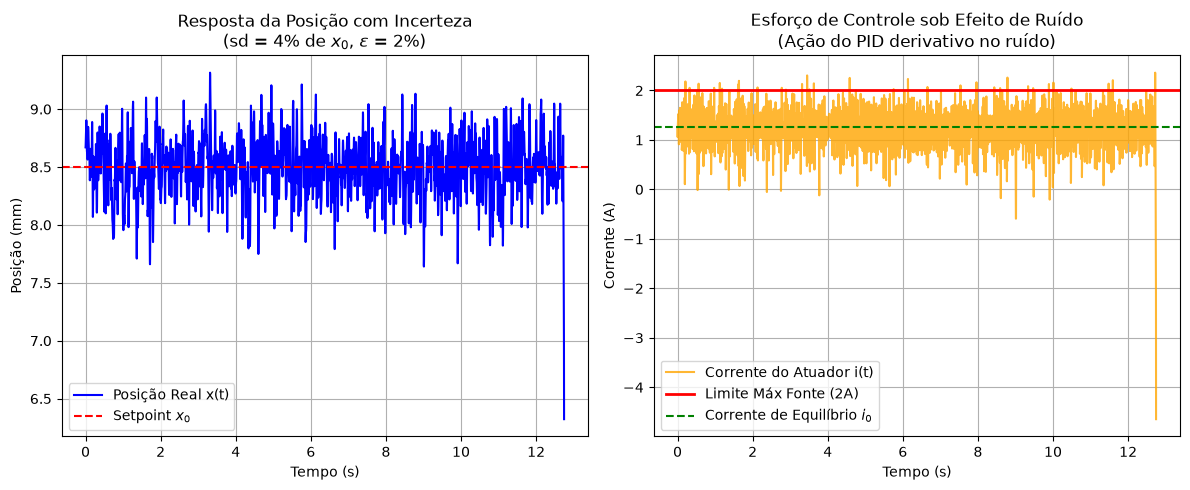

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math

# ==========================================
# 1. Parâmetros e Condições Iniciais
# ==========================================
m = 0.073      # (Kg)
g = 9.81       # (m/s^2)
k = 6.51e-5    # (Nm^2/A^2)
R = 11.0       # (Ohm)
x0 = 8.5e-3    # (m)

# Condição de equilíbrio
i0 = math.sqrt((2 * m * g * (x0**2)) / k)
u0 = R * i0

# Ganhos do PID
Kp = 8000.0 
Ki = 4000.0  
Kd = 150.0  

# Funções do modelo físico
def fm(i, x): return k/2 * i**2 / x**2
def Bl(i, x): return k/2 * i / x**2
def L(x): return k / x

# ==========================================
# 2. Gerador de Incerteza (Ruído Interpolado)
# ==========================================
def create_noise_interpolators(t_end, sd, num_points=2000):
    t_n = np.linspace(0, t_end, num_points)
    n_pos = np.random.normal(0, sd, num_points)
    
    # Derivada numérica do ruído
    dt = t_n[1] - t_n[0]
    n_vel = np.gradient(n_pos, dt) 
    
    def get_noise(t):
        return np.interp(t, t_n, n_pos), np.interp(t, t_n, n_vel)
    return get_noise

# ==========================================
# 3. Equações de Estado Ruidosas
# ==========================================
def f_noisy(t, y, get_noise):
    i, x, v, E = y
    n_p, n_v = get_noise(t)
    
    # Medição com ruído aditivo
    x_m = x + n_p
    v_m = v + n_v
    
    e = x_m - x0
    e_dot = v_m 
    
    # Controlador PID operando com sinal ruidoso
    delta_u = Kp * e + Ki * E + Kd * e_dot
    u = u0 + delta_u
    
    # Sistema Físico operando com a tensão ruidosa 'u'
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u/L(x)
    dx = v
    dv = g - fm(i,x)/m
    dE = e 
    
    return [di, dx, dv, dE]

# ==========================================
# 4. Simulação Gráfica
# ==========================================
t_end = 15 #(s) # Simular meio segundo
t_eval = np.linspace(0, t_end, 5000)

# Epsilon (2%) e Desvio Padrão do ruído (4%)
epsilon = 0.02 * x0
sd = 0.04 * x0

# Gerar sinal de ruído e condições iniciais
get_noise = create_noise_interpolators(t_end, sd)
y_0 = [i0, x0 + epsilon, 0.0, 0.0]

# Rodar o solver
sol = solve_ivp(lambda t, y: f_noisy(t, y, get_noise), 
                [0, t_end], y_0, t_eval=t_eval, method='RK45')

# ==========================================
# 5. Plotagem dos Resultados
# ==========================================
plt.figure(figsize=(12, 5))

# --- Gráfico 1: Posição ---
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1] * 1000, label='Posição Real x(t)', color='blue')
plt.axhline(x0 * 1000, color='red', linestyle='--', label='Setpoint $x_0$')
plt.title(f'Resposta da Posição com Incerteza\n(sd = 4% de $x_0$, $\epsilon$ = 2%)')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (mm)')
plt.legend()
plt.grid(True)

# --- Gráfico 2: Esforço de Controle (Corrente) ---
plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[0], label='Corrente do Atuador i(t)', color='orange', alpha=0.8)
plt.axhline(2.0, color='red', linestyle='-', linewidth=2, label='Limite Máx Fonte (2A)')
plt.axhline(i0, color='green', linestyle='--', label='Corrente de Equilíbrio $i_0$')
plt.title('Esforço de Controle sob Efeito de Ruído\n(Ação do PID derivativo no ruído)')
plt.xlabel('Tempo (s)')
plt.ylabel('Corrente (A)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()